In [4]:
import pandas as pd
df = pd.read_csv("/workspaces/AI_ML_Assignment/IOC.csv")

In [5]:
df.shape

(5306, 15)

In [6]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   str    
 1   Symbol              5306 non-null   str    
 2   Series              5306 non-null   str    
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4797 non-null   float64
 14  %Deliverble         4797 non-null   float64
dtypes: float64(11), int64(1), str(3)
memory usage: 621.9 KB


In [8]:
df["Date"] = pd.to_datetime(df["Date"].astype(str), errors="coerce")
df = df.sort_values("Date").reset_index(drop=True)

In [9]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


In [10]:
numeric_df = df.iloc[:, 3:-1]

In [11]:
numeric_df.shape

(5306, 11)

In [12]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN
1,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN
2,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN
3,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN
4,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN


In [13]:
numeric_df.isna().sum()

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
dtype: int64

In [14]:
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

In [15]:
numeric_df.isna().sum()

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64

In [16]:
numeric_df.duplicated().sum()

np.int64(0)

In [17]:
feature_names = numeric_df.columns.tolist()
num_features = df.shape[1]
print("Features used:", feature_names)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']


In [22]:
import numpy as np
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (5306, 11)


In [23]:
data

array([[2.5400000e+02, 2.6000000e+02, 2.7325000e+02, ..., 6.1276475e+11,
        1.2758000e+04, 3.8310000e+03],
       [2.7085001e+02, 2.6000000e+02, 2.6800000e+02, ..., 6.3391125e+11,
        1.2758000e+04, 3.8310000e+03],
       [2.6439999e+02, 2.6489999e+02, 2.6500000e+02, ..., 4.9263824e+11,
        1.2758000e+04, 3.8310000e+03],
       ...,
       [8.8849998e+01, 8.9199997e+01, 8.9550003e+01, ..., 5.6579894e+13,
        2.8905000e+04, 2.1473330e+06],
       [8.9400002e+01, 9.0250000e+01, 9.0500000e+01, ..., 8.0190504e+13,
        3.9431000e+04, 3.0134200e+06],
       [8.8900002e+01, 8.8599998e+01, 9.3099998e+01, ..., 2.7271081e+14,
        8.9345000e+04, 6.5543270e+06]], shape=(5306, 11), dtype=float32)

In [24]:
INPUT_STEPS = 10
OUTPUT_STEPS = 5
TRAIN_RATIO = 0.8
BATCH_SIZE = 4

In [25]:
split_idx = int(len(data) * TRAIN_RATIO)
train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)
train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [26]:
train_data.shape, test_data.shape, val_data.shape

((3395, 11), (1062, 11), (849, 11))

In [30]:
from sklearn.preprocessing import normalize
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

In [31]:
def create_sequences(data_array, input_steps=10, output_steps=5, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <=0 :
        raise ValueError("Overlap must be smaller than input steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps: i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [32]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)


print("X_train: ", X_train.shape, "y_train: ", y_train.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)
print("X_val: ", X_val.shape, "y_val: ", y_val.shape)

X_train:  (1691, 10, 11) y_train:  (1691, 5, 11)
X_test:  (524, 10, 11) y_test:  (524, 5, 11)
X_val:  (418, 10, 11) y_val:  (418, 5, 11)


In [35]:
import torch
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [36]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [37]:
import torch.nn as nn
class LSTMForecaster(nn.Module):
    def __init__(self):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(11, 10, batch_first=True)
        self.fc = nn.Linear(10, 5 * 11)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [39]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [40]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [41]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)

            loss = criterion(preds, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

Without Early Stopping

In [42]:
EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/100] | Train Loss: 0.022502 | Val Loss: 0.011326
Epoch [2/100] | Train Loss: 0.005196 | Val Loss: 0.001876
Epoch [3/100] | Train Loss: 0.000519 | Val Loss: 0.000639
Epoch [4/100] | Train Loss: 0.000102 | Val Loss: 0.000590
Epoch [5/100] | Train Loss: 0.000086 | Val Loss: 0.000575
Epoch [6/100] | Train Loss: 0.000084 | Val Loss: 0.000541
Epoch [7/100] | Train Loss: 0.000083 | Val Loss: 0.000551
Epoch [8/100] | Train Loss: 0.000081 | Val Loss: 0.000526
Epoch [9/100] | Train Loss: 0.000080 | Val Loss: 0.000530
Epoch [10/100] | Train Loss: 0.000079 | Val Loss: 0.000511
Epoch [11/100] | Train Loss: 0.000077 | Val Loss: 0.000502
Epoch [12/100] | Train Loss: 0.000076 | Val Loss: 0.000477
Epoch [13/100] | Train Loss: 0.000075 | Val Loss: 0.000470
Epoch [14/100] | Train Loss: 0.000074 | Val Loss: 0.000469
Epoch [15/100] | Train Loss: 0.000073 | Val Loss: 0.000445
Epoch [16/100] | Train Loss: 0.000072 | Val Loss: 0.000444
Epoch [17/100] | Train Loss: 0.000071 | Val Loss: 0.000450
Epoch 

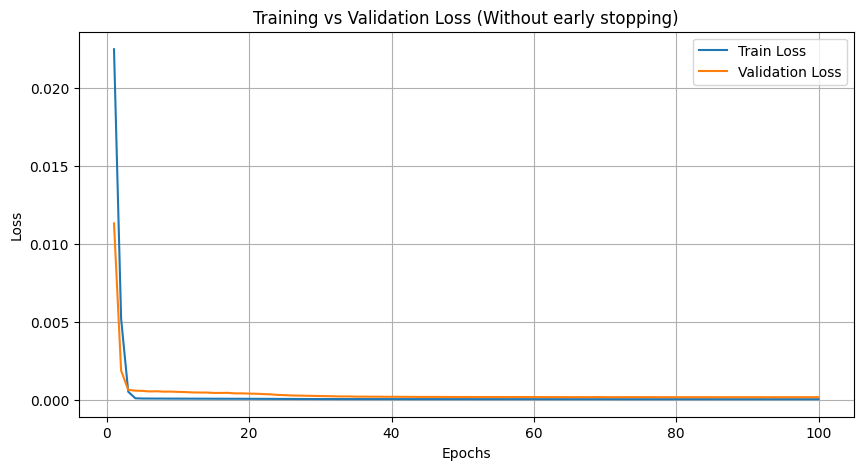

In [43]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Without early stopping)")
plt.legend()
plt.grid(True)

plt.show()

With Early Stopping

In [44]:
model = LSTMForecaster().to(device)
lr=0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

In [45]:
EPOCHS = 100
PATIENCE = 10
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _= evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss :.6f} | Val Loss: {val_loss :.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break


Epoch [1/100] | Train Loss: 0.022024 | Val Loss: 0.011177
Epoch [2/100] | Train Loss: 0.004773 | Val Loss: 0.001989
Epoch [3/100] | Train Loss: 0.000541 | Val Loss: 0.000769
Epoch [4/100] | Train Loss: 0.000117 | Val Loss: 0.000631
Epoch [5/100] | Train Loss: 0.000090 | Val Loss: 0.000612
Epoch [6/100] | Train Loss: 0.000086 | Val Loss: 0.000568
Epoch [7/100] | Train Loss: 0.000084 | Val Loss: 0.000533
Epoch [8/100] | Train Loss: 0.000082 | Val Loss: 0.000544
Epoch [9/100] | Train Loss: 0.000080 | Val Loss: 0.000520
Epoch [10/100] | Train Loss: 0.000079 | Val Loss: 0.000498
Epoch [11/100] | Train Loss: 0.000078 | Val Loss: 0.000506
Epoch [12/100] | Train Loss: 0.000077 | Val Loss: 0.000501
Epoch [13/100] | Train Loss: 0.000076 | Val Loss: 0.000483
Epoch [14/100] | Train Loss: 0.000074 | Val Loss: 0.000478
Epoch [15/100] | Train Loss: 0.000073 | Val Loss: 0.000429
Epoch [16/100] | Train Loss: 0.000071 | Val Loss: 0.000413
Epoch [17/100] | Train Loss: 0.000069 | Val Loss: 0.000393
Epoch 

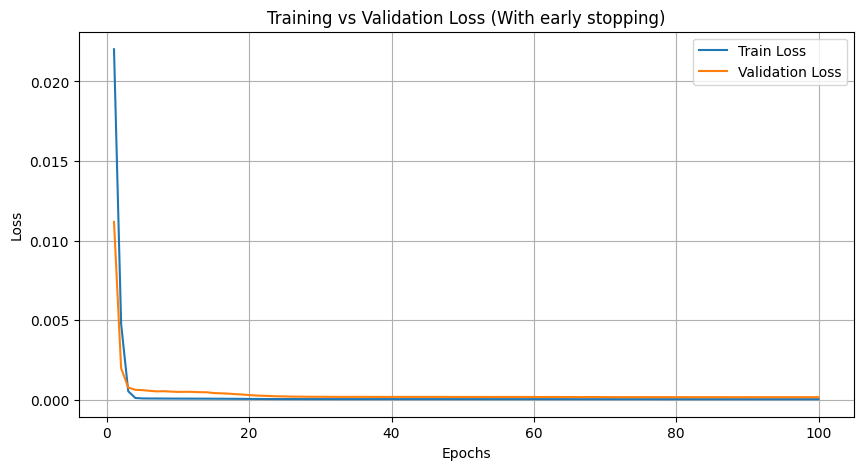

In [46]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (With early stopping)")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [48]:
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)
print("Test Loss: ", test_loss )

Test Loss:  0.00017018618898471006


In [49]:
predictions.shape, targets.shape

((524, 5, 11), (524, 5, 11))

In [50]:
predictions

array([[[0.04660189, 0.04699612, 0.04471818, ..., 0.01901665,
         0.02009927, 0.02817371],
        [0.04660362, 0.04600431, 0.0467804 , ..., 0.02031492,
         0.02011259, 0.02170793],
        [0.0466281 , 0.04660327, 0.04647245, ..., 0.02409749,
         0.02145012, 0.02375745],
        [0.04512264, 0.04636754, 0.04559901, ..., 0.02137679,
         0.02278876, 0.02760895],
        [0.03925982, 0.04578261, 0.04447509, ..., 0.02843903,
         0.02180339, 0.02147417]],

       [[0.0457232 , 0.04750927, 0.0457828 , ..., 0.03332752,
         0.02259438, 0.037596  ],
        [0.04721795, 0.04606573, 0.04812666, ..., 0.03128426,
         0.02084385, 0.02792523],
        [0.04903024, 0.04812566, 0.04684956, ..., 0.03234934,
         0.02039604, 0.03024589],
        [0.04634978, 0.04557369, 0.04533828, ..., 0.02782914,
         0.02108558, 0.03212516],
        [0.04235175, 0.04579325, 0.04740964, ..., 0.03395347,
         0.02065164, 0.0301983 ]],

       [[0.04720201, 0.04559117, 0.0

In [51]:
preds_2d = predictions.reshape(-1, predictions.shape[-1])
targets_2d = targets.reshape(-1, targets.shape[-1])
preds_2d.shape, targets_2d.shape

((2620, 11), (2620, 11))

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(targets_2d, preds_2d)
rmse = np.sqrt(mse)
mae = mean_absolute_error(targets_2d, preds_2d)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

MSE: 0.00017018614744301885
RMSE: 0.013045541285934397
MAE: 0.005435241386294365


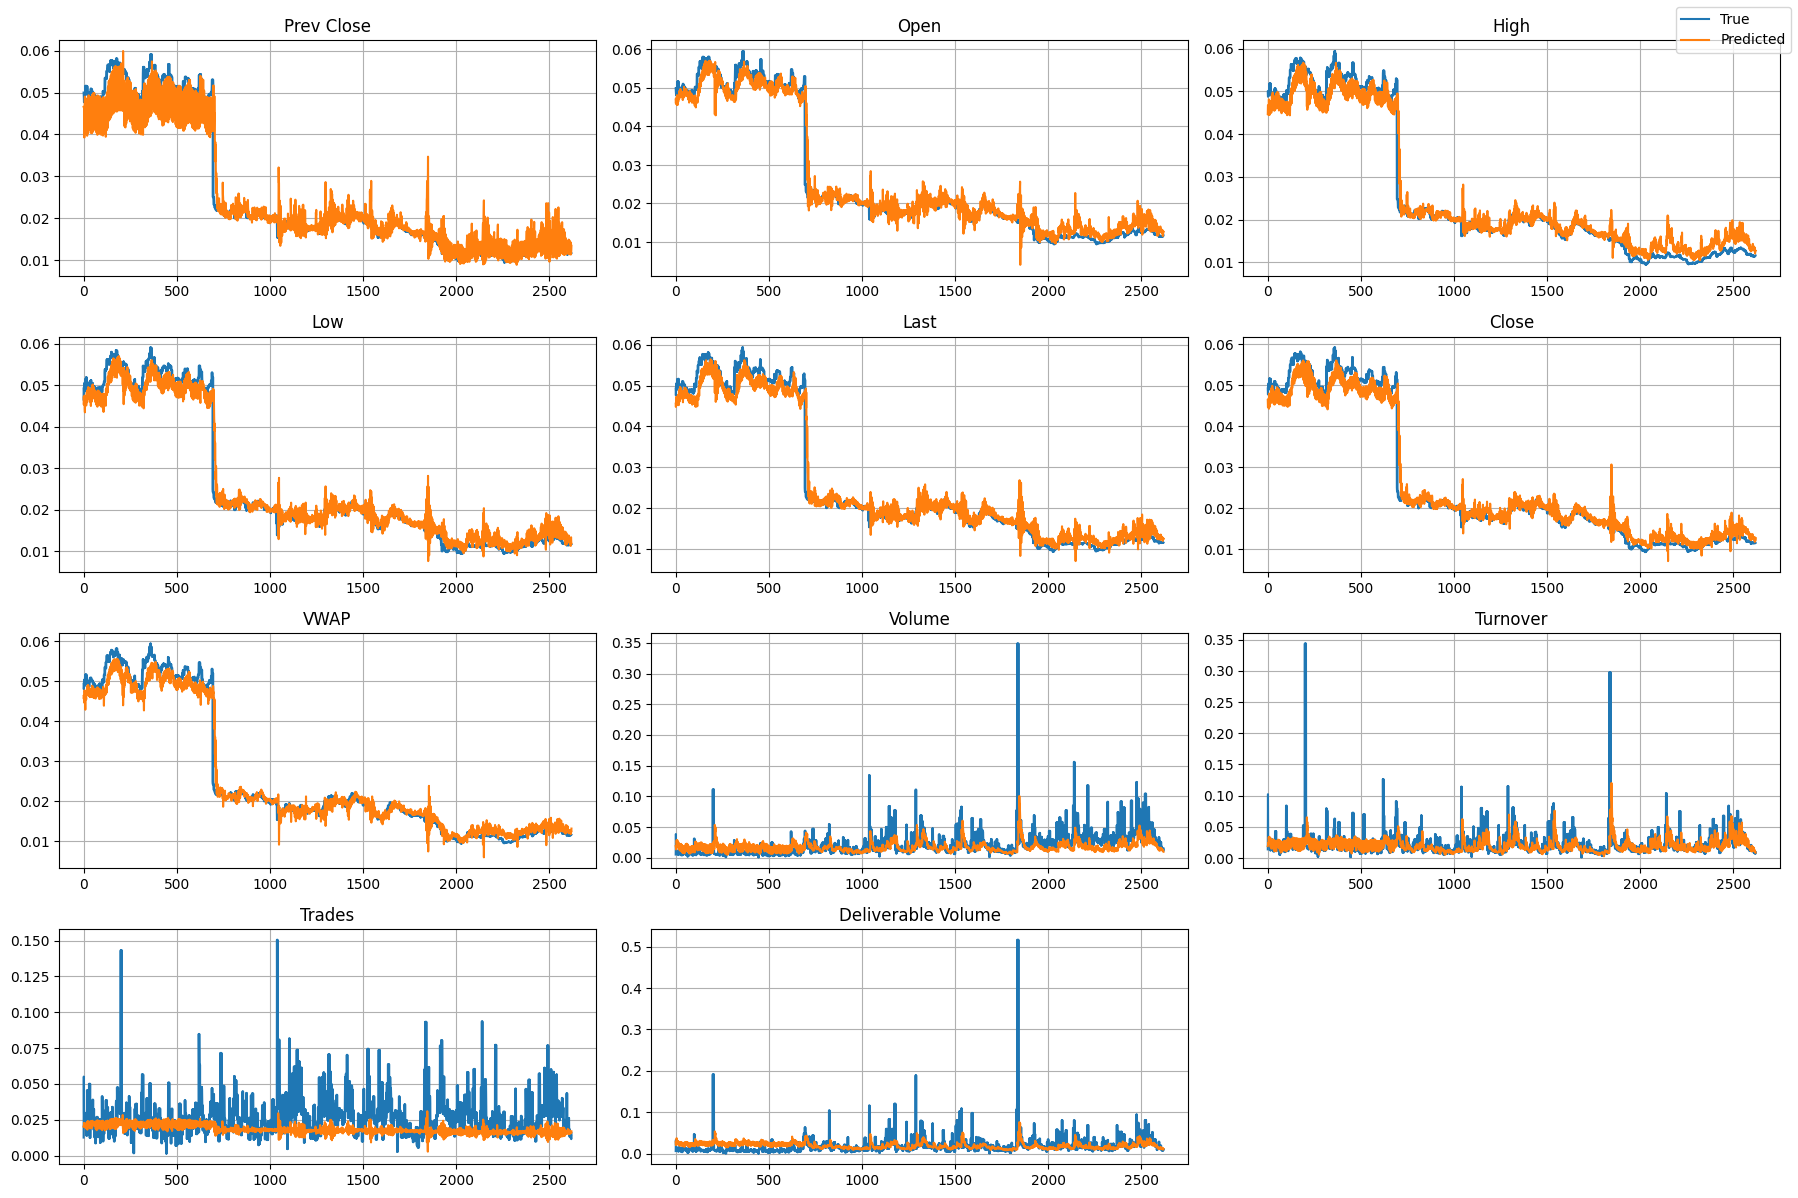

In [53]:
import matplotlib.pyplot as plt

num_features = predictions.shape[-1]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i in range(num_features):
    pred_feature = predictions[:, :, i].reshape(-1)
    true_feature = targets[:, :, i].reshape(-1)

    axes[i].plot(true_feature, label="True")
    axes[i].plot(pred_feature, label="Predicted")
    axes[i].set_title(feature_names[i])
    axes[i].grid(True)

fig.delaxes(axes[-1])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

10-Fold Cross Validation

In [54]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10)

all_train_losses = []
all_val_losses = []

fold = 1

for train_idx, val_idx in tscv.split(train_data1):

    print(f"\nFold {fold}")

    train_data = train_data1[train_idx]
    val_data = train_data1[val_idx]

    train_data_norm = normalize(train_data, axis=0)
    val_data_norm = normalize(val_data, axis=0)

    X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS)
    X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS)

    train_dataset = TimeSeriesDataset(X_train, y_train)
    val_dataset = TimeSeriesDataset(X_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = LSTMForecaster().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    patience = 10
    epochs_no_improve = 0

    train_losses = []
    val_losses = []

    for epoch in range(100):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _, _ = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Fold {fold} | Epoch {epoch+1} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0

            torch.save(model.state_dict(), f"best_model_fold_{fold}.pt")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

    print(f"Fold {fold} Best Val Loss: {best_val_loss:.6f}")
    fold += 1


Fold 1
Fold 1 | Epoch 1 | Train: 0.037394 | Val: 0.038104
Fold 1 | Epoch 2 | Train: 0.036561 | Val: 0.037274
Fold 1 | Epoch 3 | Train: 0.035746 | Val: 0.036460
Fold 1 | Epoch 4 | Train: 0.034944 | Val: 0.035658
Fold 1 | Epoch 5 | Train: 0.034154 | Val: 0.034868
Fold 1 | Epoch 6 | Train: 0.033372 | Val: 0.034087
Fold 1 | Epoch 7 | Train: 0.032599 | Val: 0.033313
Fold 1 | Epoch 8 | Train: 0.031832 | Val: 0.032547
Fold 1 | Epoch 9 | Train: 0.031072 | Val: 0.031787
Fold 1 | Epoch 10 | Train: 0.030318 | Val: 0.031033
Fold 1 | Epoch 11 | Train: 0.029569 | Val: 0.030284
Fold 1 | Epoch 12 | Train: 0.028826 | Val: 0.029541
Fold 1 | Epoch 13 | Train: 0.028088 | Val: 0.028804
Fold 1 | Epoch 14 | Train: 0.027355 | Val: 0.028071
Fold 1 | Epoch 15 | Train: 0.026628 | Val: 0.027344
Fold 1 | Epoch 16 | Train: 0.025906 | Val: 0.026623
Fold 1 | Epoch 17 | Train: 0.025190 | Val: 0.025908
Fold 1 | Epoch 18 | Train: 0.024481 | Val: 0.025199
Fold 1 | Epoch 19 | Train: 0.023778 | Val: 0.024497


Fold 1 | Epoch 20 | Train: 0.023082 | Val: 0.023802
Fold 1 | Epoch 21 | Train: 0.022394 | Val: 0.023114
Fold 1 | Epoch 22 | Train: 0.021713 | Val: 0.022435
Fold 1 | Epoch 23 | Train: 0.021042 | Val: 0.021764
Fold 1 | Epoch 24 | Train: 0.020379 | Val: 0.021102
Fold 1 | Epoch 25 | Train: 0.019726 | Val: 0.020449
Fold 1 | Epoch 26 | Train: 0.019083 | Val: 0.019807
Fold 1 | Epoch 27 | Train: 0.018451 | Val: 0.019175
Fold 1 | Epoch 28 | Train: 0.017829 | Val: 0.018553
Fold 1 | Epoch 29 | Train: 0.017218 | Val: 0.017943
Fold 1 | Epoch 30 | Train: 0.016619 | Val: 0.017344
Fold 1 | Epoch 31 | Train: 0.016032 | Val: 0.016757
Fold 1 | Epoch 32 | Train: 0.015456 | Val: 0.016182
Fold 1 | Epoch 33 | Train: 0.014893 | Val: 0.015619
Fold 1 | Epoch 34 | Train: 0.014342 | Val: 0.015069
Fold 1 | Epoch 35 | Train: 0.013804 | Val: 0.014531
Fold 1 | Epoch 36 | Train: 0.013278 | Val: 0.014005
Fold 1 | Epoch 37 | Train: 0.012765 | Val: 0.013492
Fold 1 | Epoch 38 | Train: 0.012264 | Val: 0.012992
Fold 1 | Epo

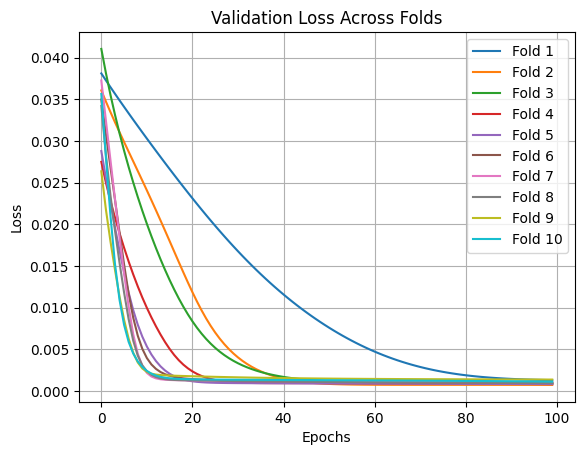

In [55]:
for i in range(len(all_train_losses)):
    plt.plot(all_val_losses[i], label=f"Fold {i+1}")

plt.title("Validation Loss Across Folds")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()